
========== Biden Dataset Interaction Network ==========
  biden <-> trump | Freq: 59942 | Sent: -0.42 (Neg)
  biden <-> vote | Freq: 37698 | Sent: -0.26 (Neg)
  trump <-> vote | Freq: 19160 | Sent: -0.43 (Neg)
  biden <-> democracy | Freq: 2226 | Sent: -0.21 (Neg)
  biden <-> justice | Freq: 1563 | Sent: -0.35 (Neg)
  vote <-> democracy | Freq: 1197 | Sent: -0.31 (Neg)
  trump <-> justice | Freq: 1106 | Sent: -0.39 (Neg)
  trump <-> democracy | Freq: 1055 | Sent: -0.46 (Neg)
  biden <-> future | Freq: 979 | Sent: -0.07 (Neg)
  vote <-> justice | Freq: 947 | Sent: -0.33 (Neg)
  biden <-> economy | Freq: 907 | Sent: -0.45 (Neg)
  biden <-> jobs | Freq: 885 | Sent: -0.51 (Neg)
  biden <-> healthcare | Freq: 778 | Sent: -0.41 (Neg)
  biden <-> climate | Freq: 662 | Sent: -0.20 (Neg)
  biden <-> rights | Freq: 631 | Sent: -0.30 (Neg)
  biden <-> trust | Freq: 585 | Sent: -0.40 (Neg)
  trump <-> economy | Freq: 516 | Sent: -0.53 (Neg)
  trump <-> healthcare | Freq: 403 | Sent: -0.54 (Neg)
 

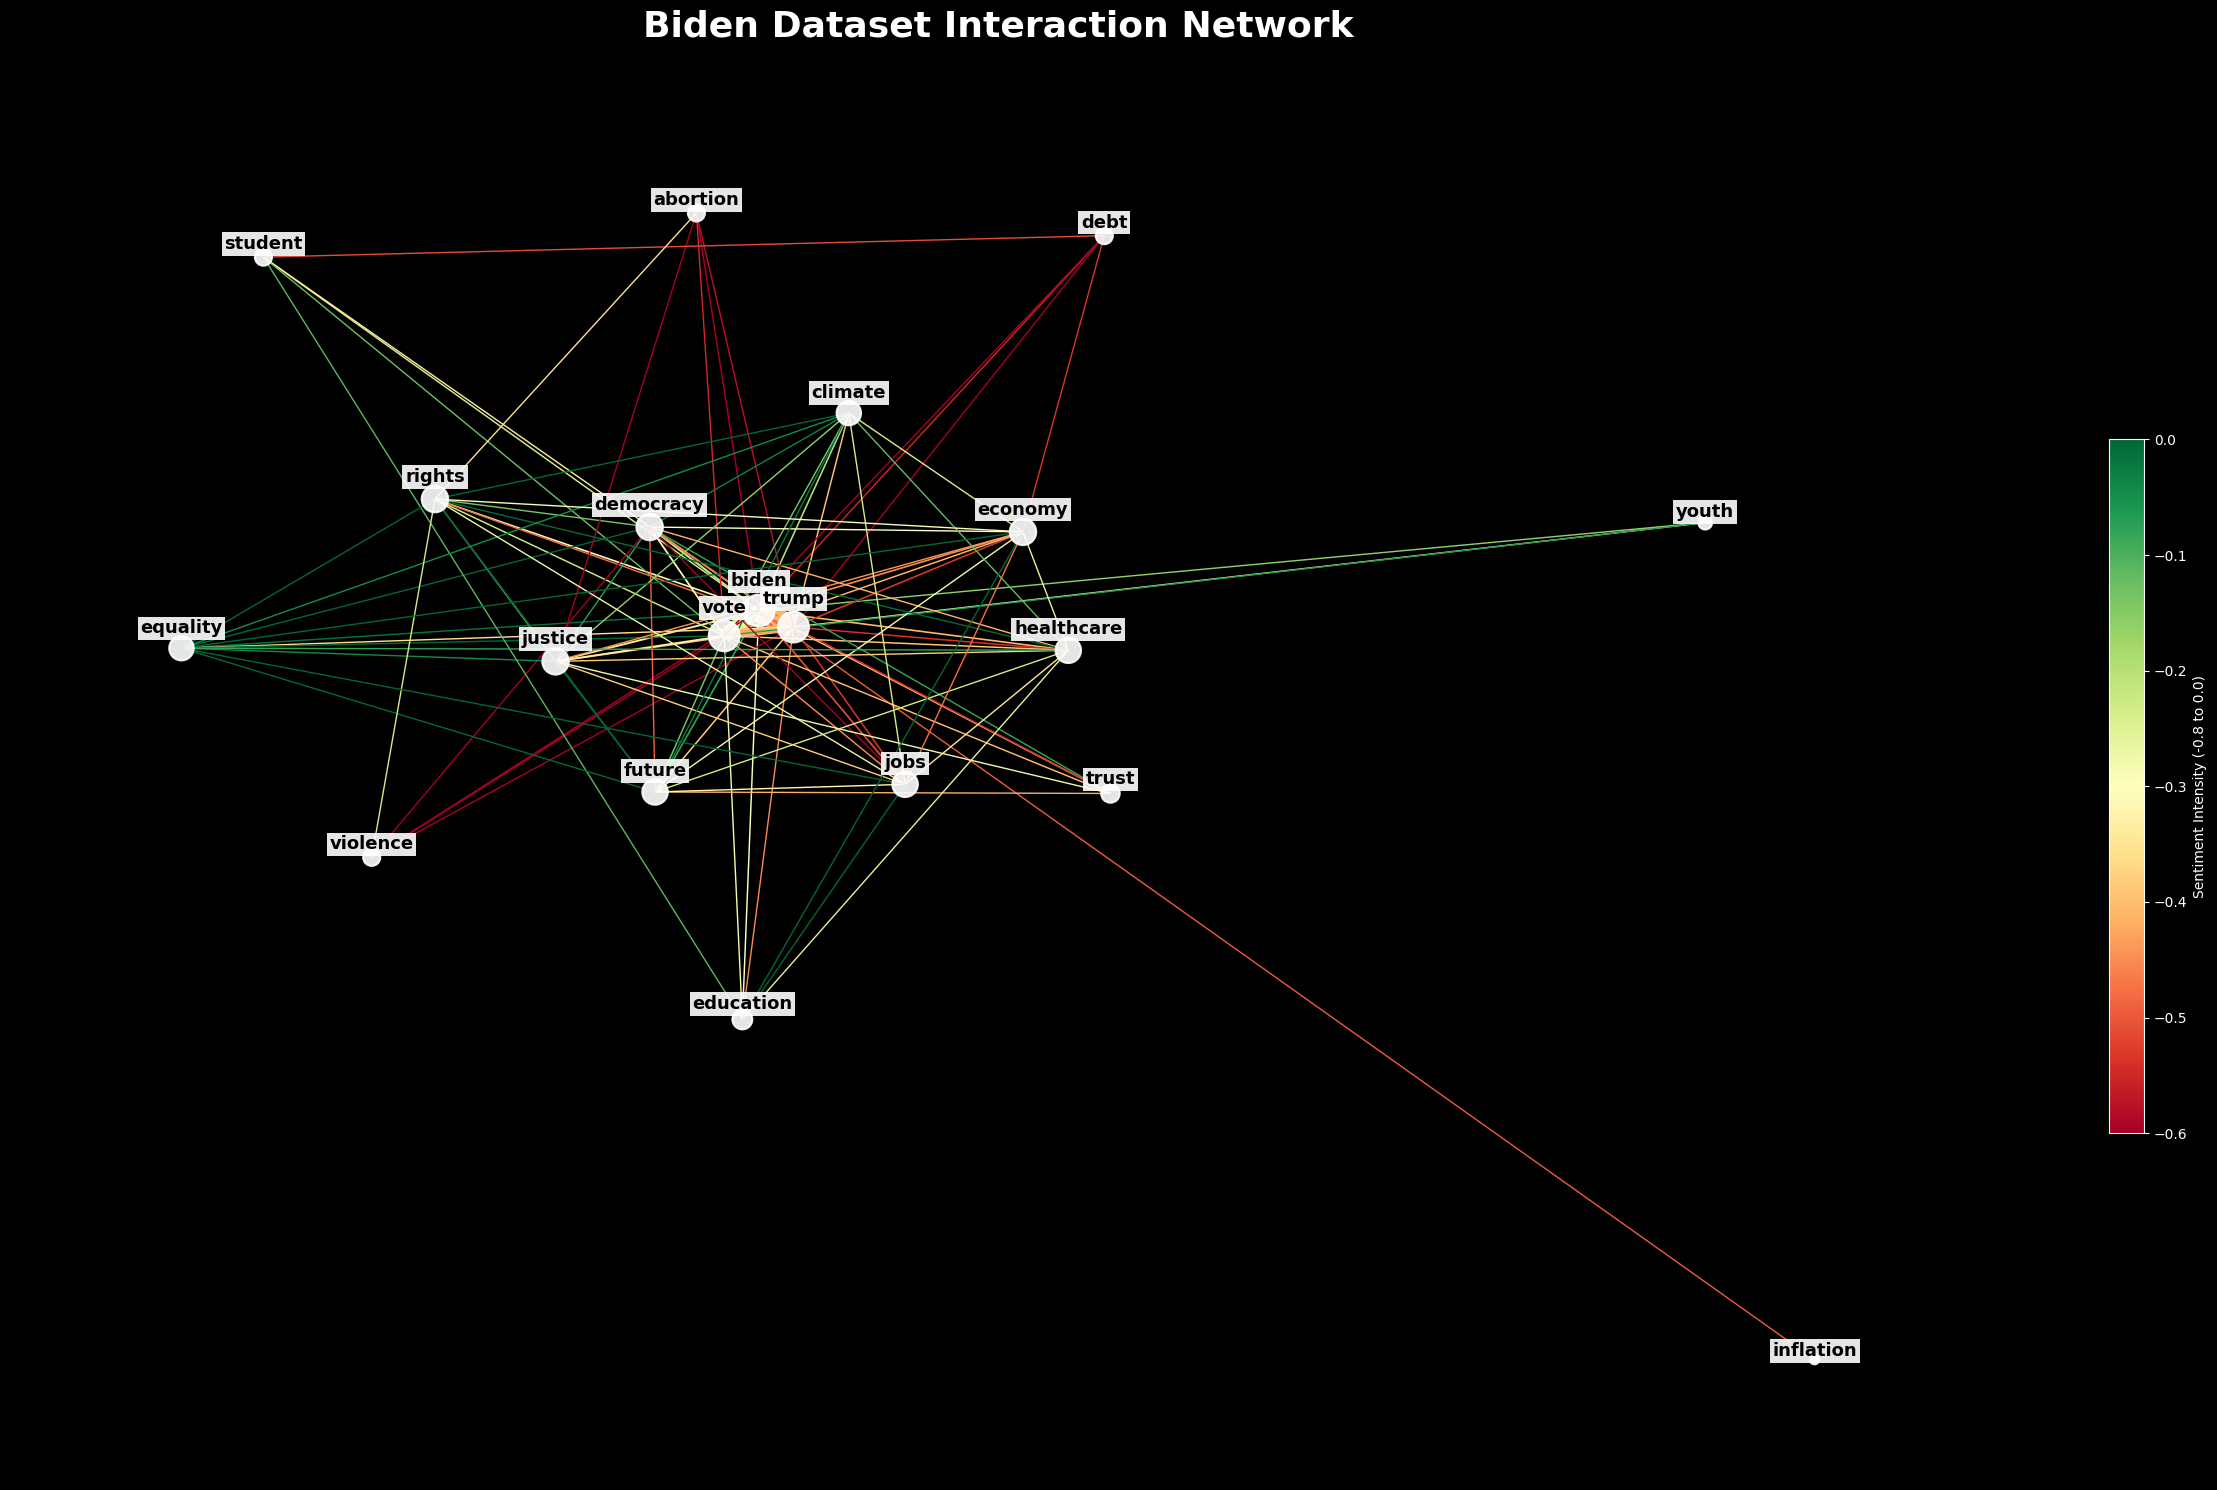


========== Trump Dataset Interaction Network ==========
  biden <-> trump | Freq: 54285 | Sent: -0.46 (Neg)
  trump <-> vote | Freq: 39147 | Sent: -0.49 (Neg)
  biden <-> vote | Freq: 18275 | Sent: -0.48 (Neg)
  trump <-> democracy | Freq: 2400 | Sent: -0.60 (Neg)
  trump <-> economy | Freq: 1376 | Sent: -0.55 (Neg)
  trump <-> justice | Freq: 1313 | Sent: -0.49 (Neg)
  trump <-> healthcare | Freq: 1172 | Sent: -0.61 (Neg)
  vote <-> democracy | Freq: 1121 | Sent: -0.55 (Neg)
  trump <-> violence | Freq: 1072 | Sent: -0.82 (Neg)
  trump <-> jobs | Freq: 905 | Sent: -0.59 (Neg)
  trump <-> trust | Freq: 889 | Sent: -0.57 (Neg)
  biden <-> democracy | Freq: 870 | Sent: -0.45 (Neg)
  trump <-> climate | Freq: 816 | Sent: -0.65 (Neg)
  trump <-> future | Freq: 811 | Sent: -0.38 (Neg)
  trump <-> rights | Freq: 810 | Sent: -0.59 (Neg)
  trump <-> debt | Freq: 679 | Sent: -0.71 (Neg)
  biden <-> violence | Freq: 518 | Sent: -0.81 (Neg)
  biden <-> economy | Freq: 451 | Sent: -0.51 (Neg)
  b

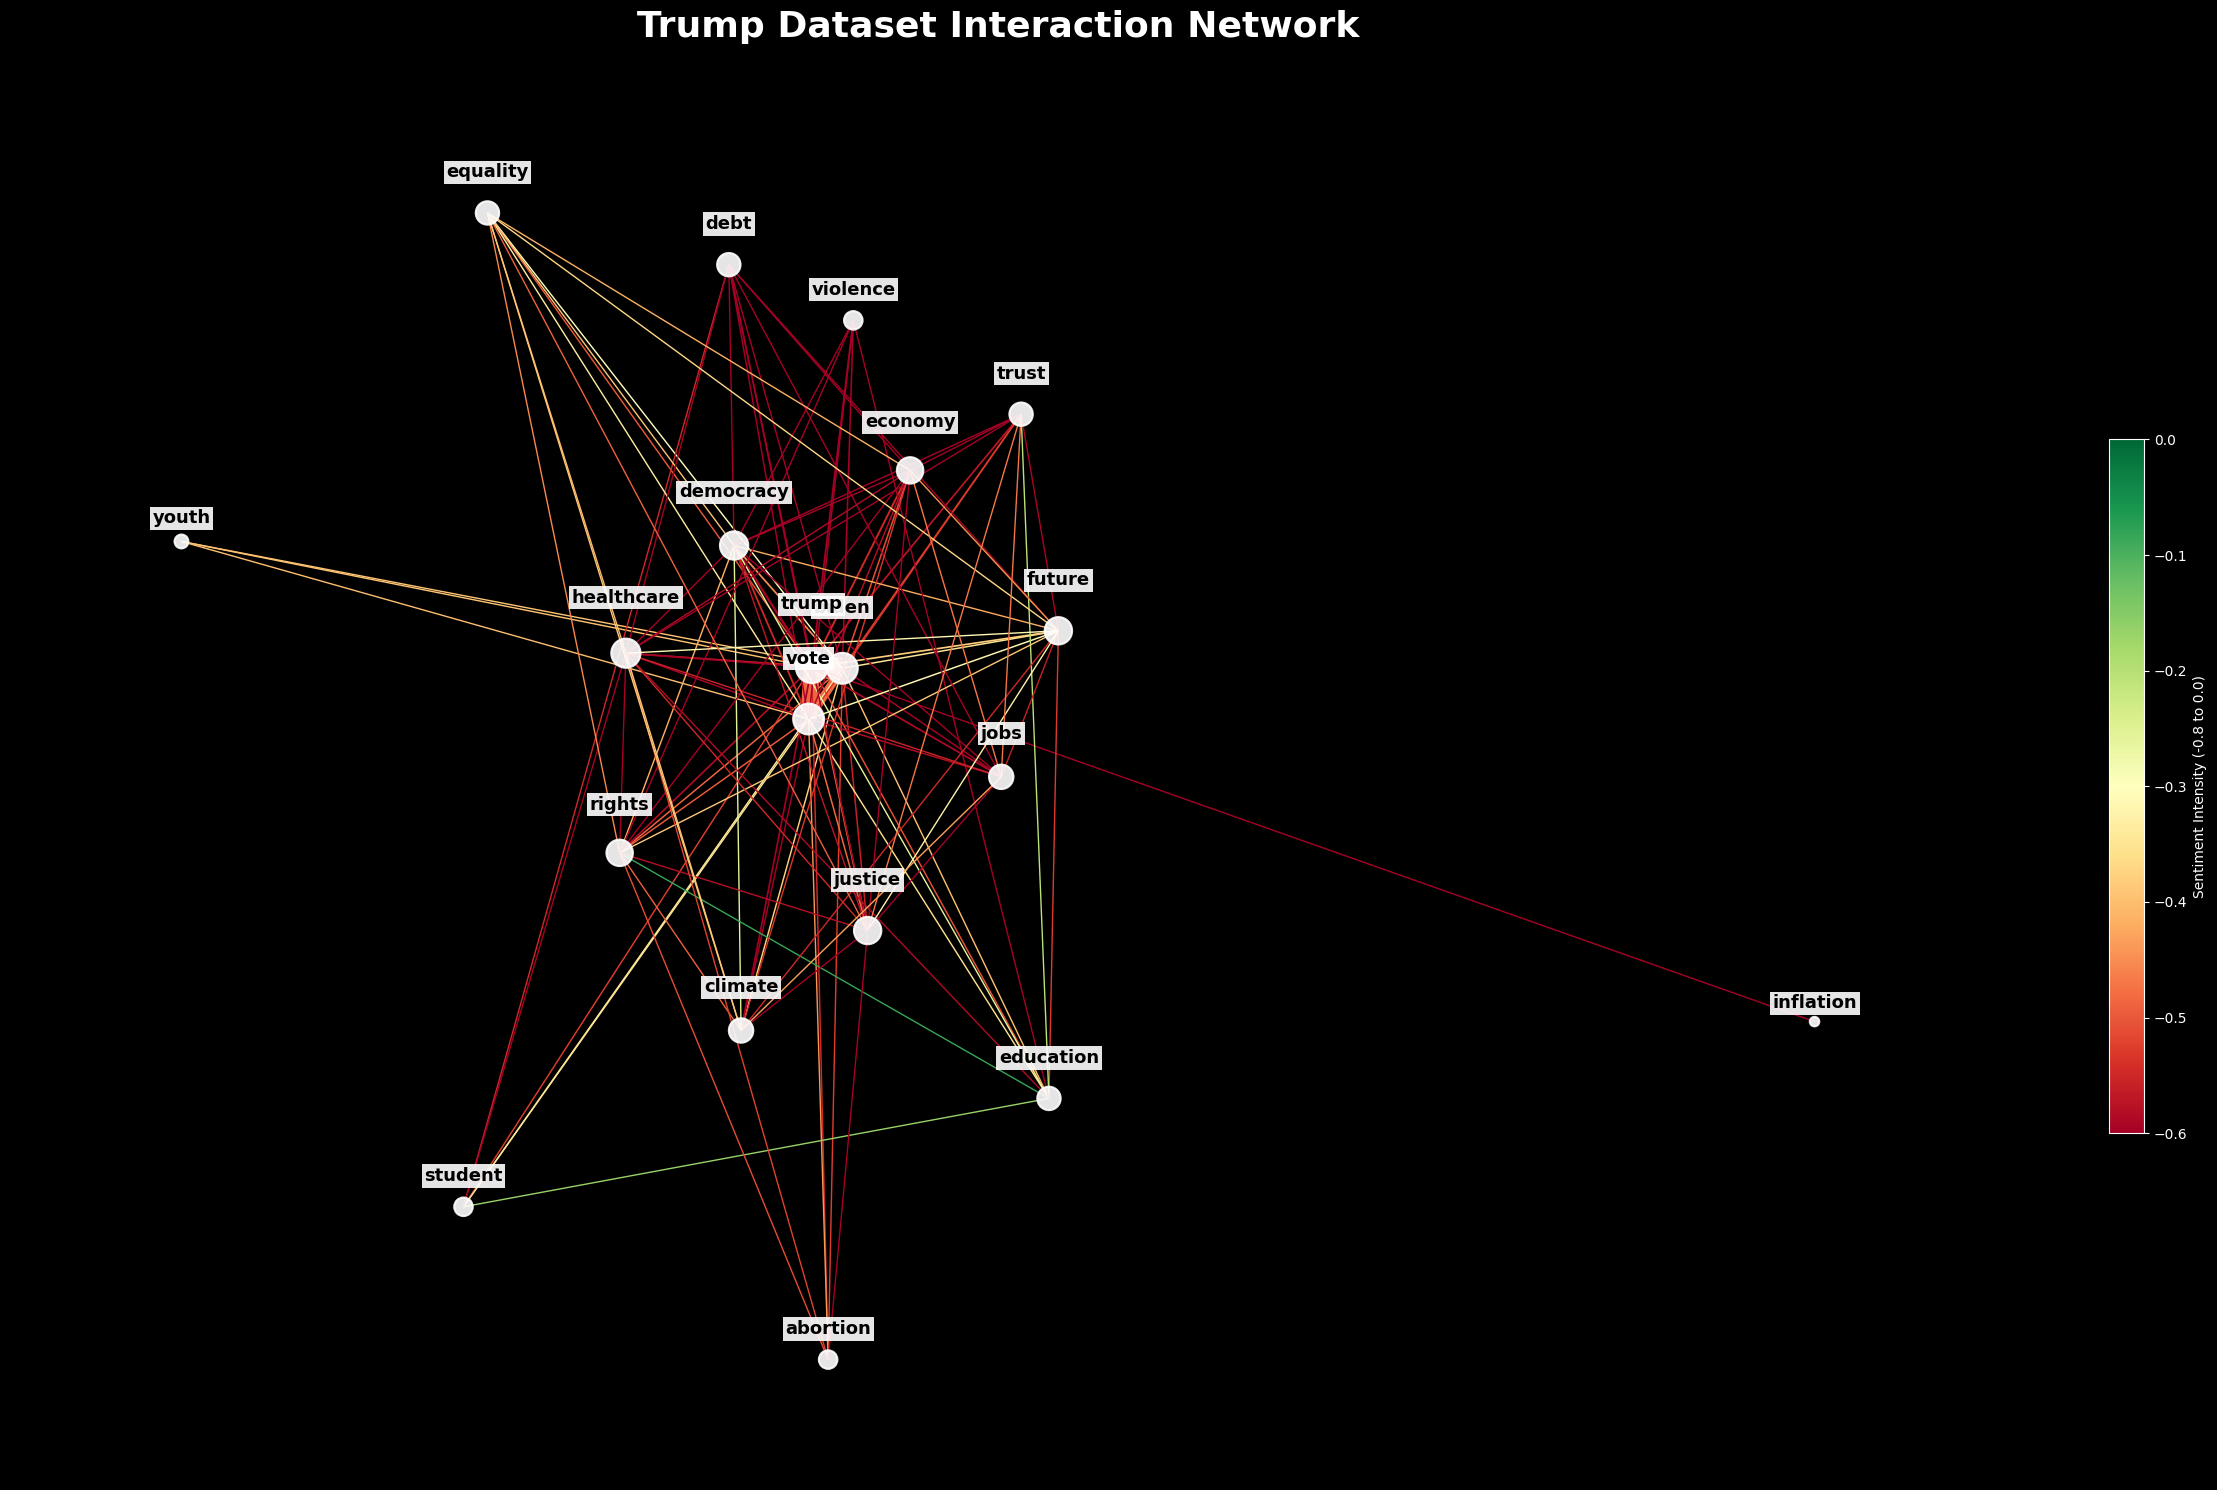


========== Full Combined Interaction Network ==========
  biden <-> trump | Freq: 114227 | Sent: -0.43 (Neg)
  trump <-> vote | Freq: 58307 | Sent: -0.47 (Neg)
  biden <-> vote | Freq: 55973 | Sent: -0.33 (Neg)
  trump <-> democracy | Freq: 3455 | Sent: -0.56 (Neg)
  biden <-> democracy | Freq: 3096 | Sent: -0.28 (Neg)
  trump <-> justice | Freq: 2419 | Sent: -0.44 (Neg)
  vote <-> democracy | Freq: 2318 | Sent: -0.43 (Neg)
  biden <-> justice | Freq: 1926 | Sent: -0.39 (Neg)
  trump <-> economy | Freq: 1892 | Sent: -0.54 (Neg)
  trump <-> healthcare | Freq: 1575 | Sent: -0.59 (Neg)
  biden <-> economy | Freq: 1358 | Sent: -0.47 (Neg)
  biden <-> future | Freq: 1288 | Sent: -0.14 (Neg)
  trump <-> jobs | Freq: 1276 | Sent: -0.57 (Neg)
  trump <-> violence | Freq: 1264 | Sent: -0.81 (Neg)
  vote <-> justice | Freq: 1264 | Sent: -0.37 (Neg)
  biden <-> jobs | Freq: 1211 | Sent: -0.54 (Neg)
  trump <-> future | Freq: 1185 | Sent: -0.38 (Neg)
  biden <-> healthcare | Freq: 1143 | Sent: -0

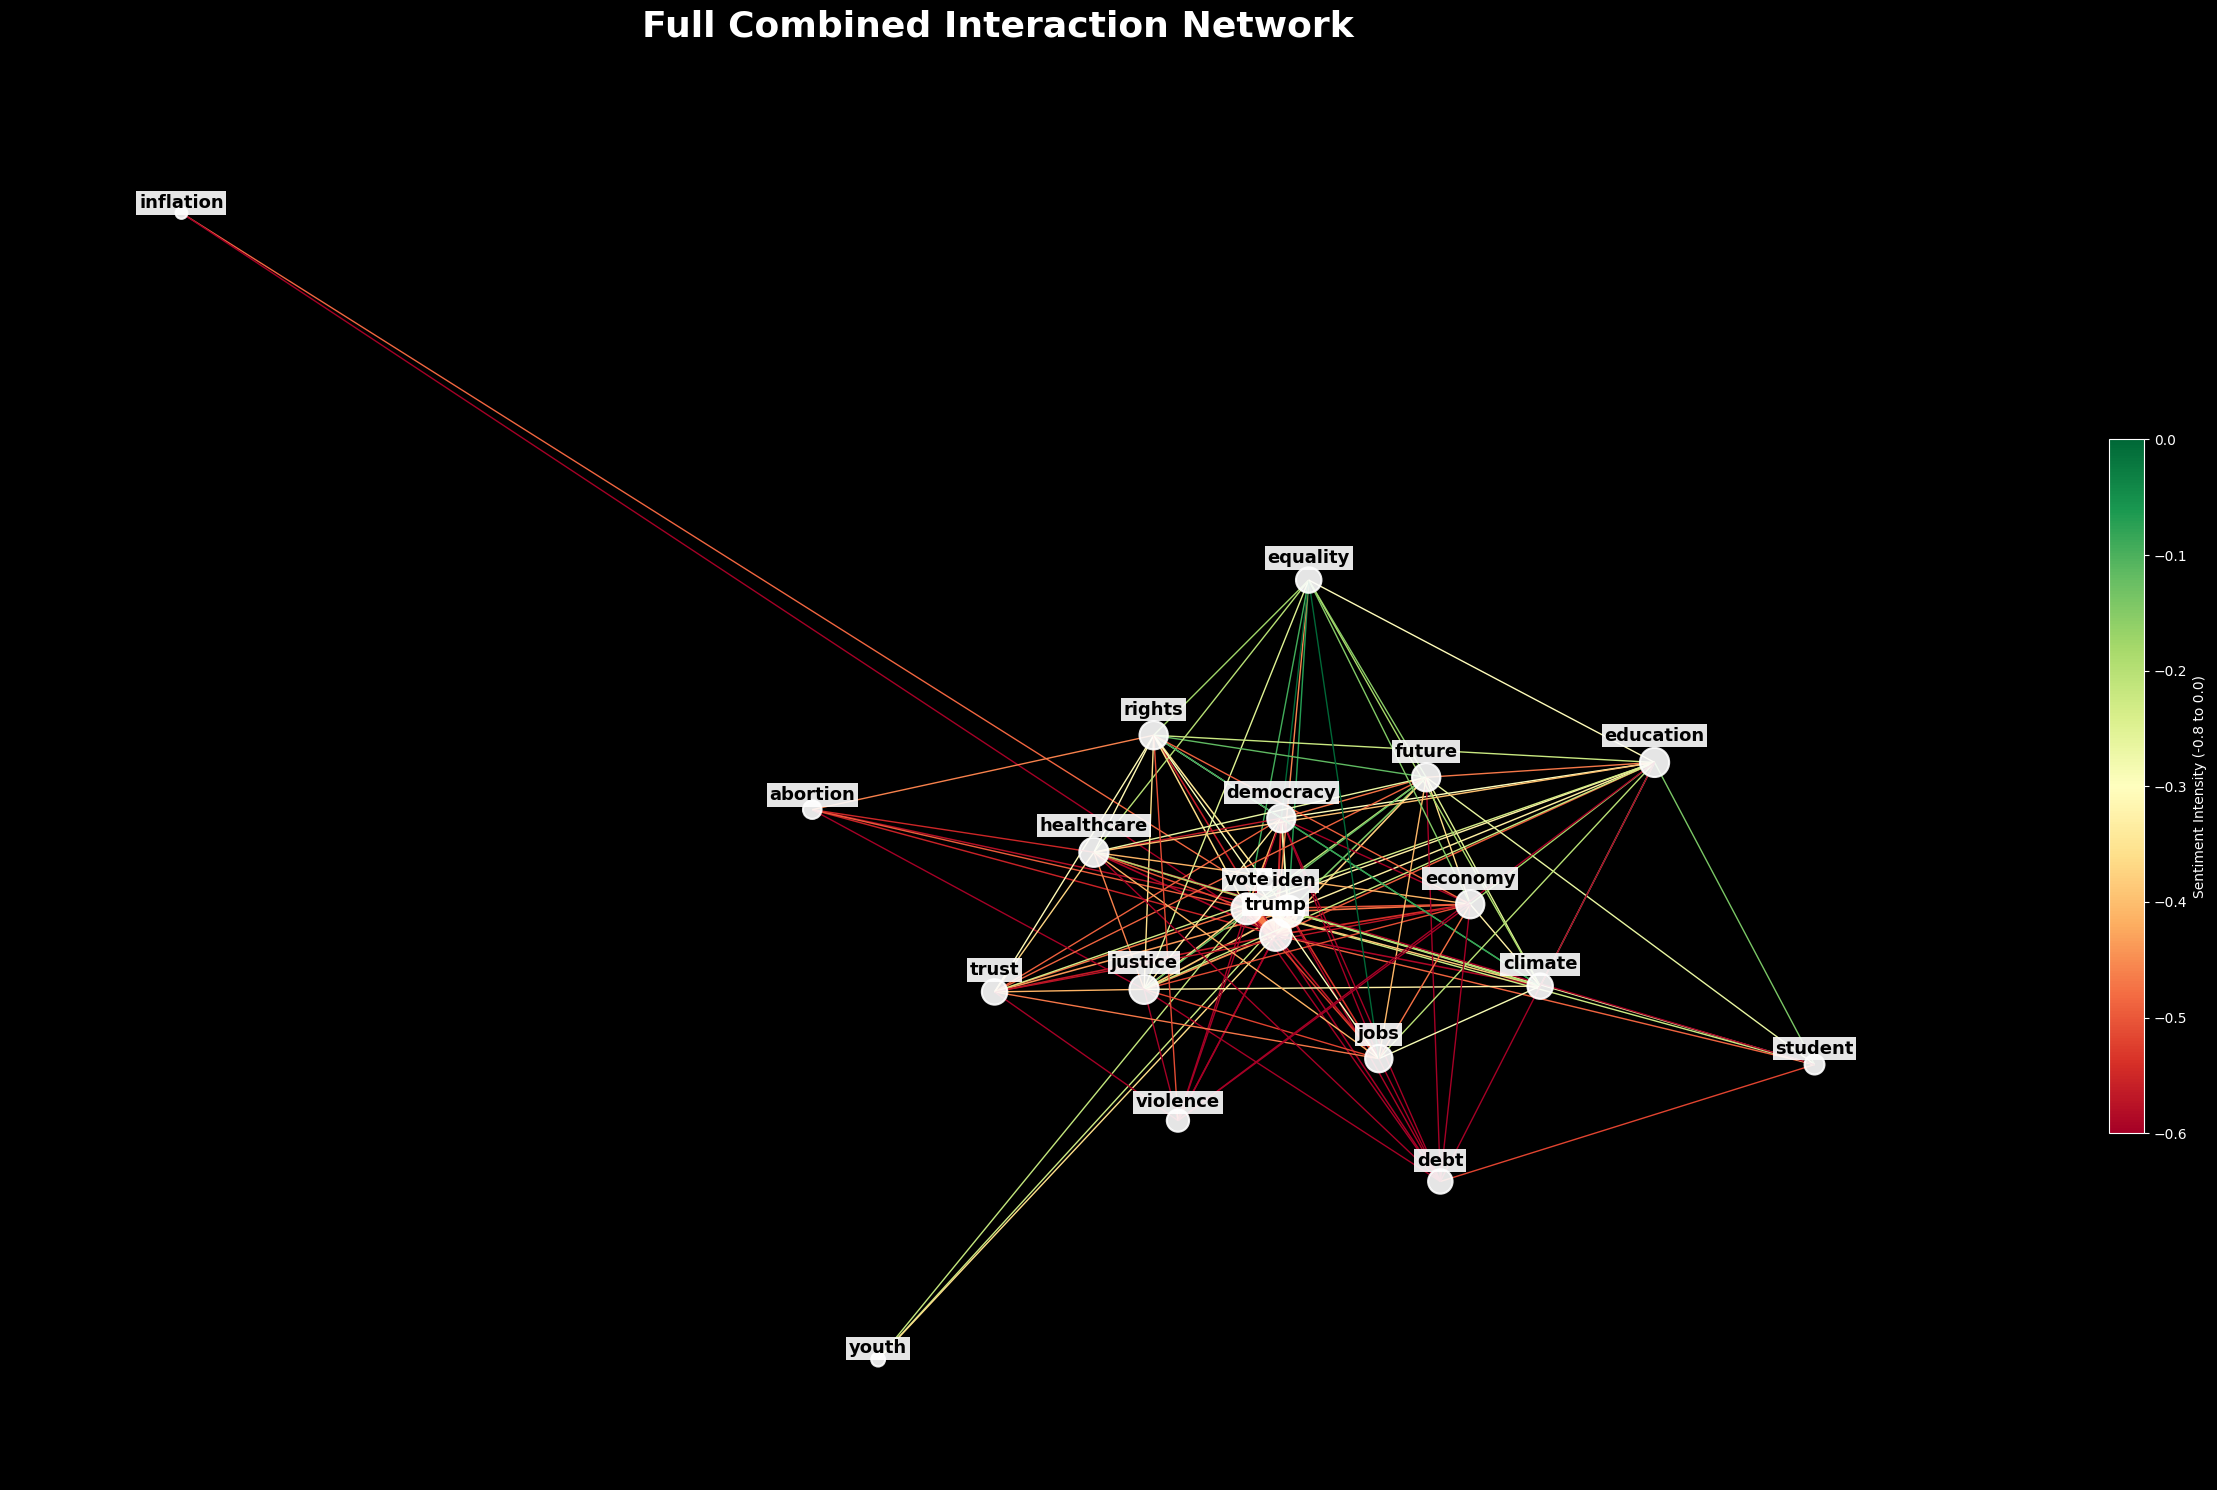

In [ ]:

import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

biden_df = pd.read_csv('translated_data/biden_translated.csv')
trump_df = pd.read_csv('translated_data/trump_translated.csv')
combined_df = pd.concat([biden_df, trump_df])

us_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 
    'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 
    'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 
    'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 
    'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 
    'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 
    'West Virginia', 'Wisconsin', 'Wyoming'
]

biden_df = biden_df[biden_df['state'].isin(us_states)]
trump_df = trump_df[trump_df['state'].isin(us_states)]
combined_df = combined_df[combined_df['state'].isin(us_states)]

SENTIMENT_COL = 'sentiment_score'

political_keywords = [
    'vote', 'youth', 'student','biden', 'trump', 'democracy', 'climate', 
    'debt', 'healthcare','economy', 'inflation', 'abortion', 'rights', 
    'future', 'violence', 'trust', 'justice', 'equality', 'education', 'jobs'
]

def extract_keywords(text):
    if not isinstance(text, str): return []
    text = text.lower()
    found = [word for word in political_keywords if word in text]
    return list(set(found))

biden_df['keywords'] = biden_df['tweet'].apply(extract_keywords)
trump_df['keywords'] = trump_df['tweet'].apply(extract_keywords)
combined_df['keywords'] = combined_df['tweet'].apply(extract_keywords)

def generate_fixed_network(df, title, threshold=5, top_n=20):
    pair_data = {}
    for _, row in df.iterrows():
        tags = row['keywords']
        score = row.get('sentiment_score', 0)
        if len(tags) > 1:
            for pair in combinations(sorted(tags), 2):
                if pair not in pair_data: pair_data[pair] = []
                pair_data[pair].append(score)

    G = nx.Graph()
    for (tag1, tag2), scores in pair_data.items():
        if len(scores) > threshold:
            avg_s = sum(scores) / len(scores)
            G.add_edge(tag1, tag2, weight=len(scores), sentiment=avg_s)

    print(f"\n{'='*10} {title} {'='*10}")
    edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    for u, v, data in edges_sorted[:top_n]:
        sentiment_label = "Pos" if data['sentiment'] > 0.05 else "Neg" if data['sentiment'] < -0.05 else "Neu"
        print(f"  {u} <-> {v} | Freq: {data['weight']} | Sent: {data['sentiment']:.2f} ({sentiment_label})")

    # high k to give those big nodes plenty of room
    pos = nx.spring_layout(G, k=10.0, iterations=150)
    centrality = nx.degree_centrality(G)
    
    node_sizes = [20 + (centrality[node] * 500) for node in G.nodes()]

    plt.style.use('dark_background')
    plt.figure(figsize=(25, 15))
    
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [1 + (w / max_w) * 15 for w in weights]
    edge_colors = [G[u][v]['sentiment'] for u, v in G.edges()]
    
    edges = nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, 
                                   edge_cmap=plt.cm.RdYlGn, edge_vmin=-0.6, edge_vmax=0.0, alpha=1.0)

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#ffffff",
                           edgecolors='white', linewidths=1.5, alpha=0.9)

 
    label_pos = {}
    for node, coords in pos.items():

        shift = 0.01 + (centrality[node] * 0.03) 
        label_pos[node] = (coords[0], coords[1] + shift)
    
    nx.draw_networkx_labels(G, label_pos, font_size=13, font_weight='bold',
                            bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2))

    plt.colorbar(edges, label="Sentiment Intensity (-0.8 to 0.0)", shrink=0.5)
    plt.title(title, fontsize=26, fontweight='bold', pad=40)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


generate_fixed_network(biden_df, "Biden Dataset Interaction Network")
generate_fixed_network(trump_df, "Trump Dataset Interaction Network")
generate_fixed_network(combined_df, "Full Combined Interaction Network")